# DX 704 Week 3 Project

This week's project will give you practice with optimizing choices for bandit algorithms.
You will be given access to the bandit problem via a blackbox object, and you will investigate the bandit rewards to pick a suitable algorithm.

The full project description, a template notebook and supporting code are available on GitHub: [Project 3 Materials](https://github.com/bu-cds-dx704/dx704-project-03).


## Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Part 1: Pick a Bandit Algorithm

Experiment with the multi-armed bandit interface using seed 0 to learn about the distribution of rewards and decide what kind of bandit algorithm will be appropriate.
A histogram will likely be helpful.

In [1]:
# DO NOT CHANGE

import numpy as np

class BanditProblem(object):
    def __init__(self, seed):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.num_arms = 3
        self.ns = self.rng.integers(low=1, high=10, size=self.num_arms)
        self.ps = self.rng.uniform(low=0.2, high=0.4, size=self.num_arms)

    def get_num_arms(self):
        return self.num_arms

    def get_reward(self, arm):
        if arm < 0 or arm >= self.num_arms:
            raise ValueError("Invalid arm")

        x = self.rng.uniform()
        x *= self.rng.binomial(self.ns[arm], self.ps[arm])

        return x


In [2]:
bandit0 = BanditProblem(0)

In [3]:
bandit0.get_num_arms()

3

In [4]:
bandit0.get_reward(arm=0)

1.8255111545554434

Arm 0:
  Mean: 0.8352
  Std: 0.8149
  Min: 0.0000
  Max: 6.7825

Arm 1:
  Mean: 0.6091
  Std: 0.6719
  Min: 0.0000
  Max: 4.8481

Arm 2:
  Mean: 0.9092
  Std: 0.8255
  Min: 0.0000
  Max: 4.9967



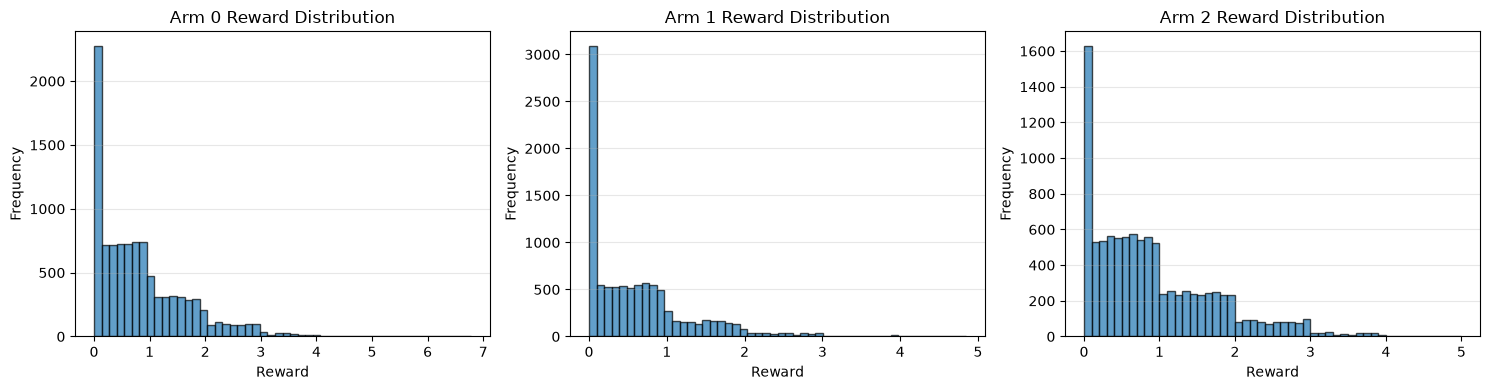

In [5]:
import matplotlib.pyplot as plt

# Collect rewards from each arm to understand their distributions
num_samples = 10000
arm_rewards = {arm: [] for arm in range(bandit0.get_num_arms())}

for arm in range(bandit0.get_num_arms()):
    for _ in range(num_samples):
        reward = bandit0.get_reward(arm)
        arm_rewards[arm].append(reward)

# Create histograms for each arm
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for arm in range(bandit0.get_num_arms()):
    axes[arm].hist(arm_rewards[arm], bins=50, edgecolor='black', alpha=0.7)
    axes[arm].set_title(f'Arm {arm} Reward Distribution')
    axes[arm].set_xlabel('Reward')
    axes[arm].set_ylabel('Frequency')
    axes[arm].grid(axis='y', alpha=0.3)
    
    # Print statistics
    rewards = arm_rewards[arm]
    print(f"Arm {arm}:")
    print(f"  Mean: {np.mean(rewards):.4f}")
    print(f"  Std: {np.std(rewards):.4f}")
    print(f"  Min: {np.min(rewards):.4f}")
    print(f"  Max: {np.max(rewards):.4f}")
    print()

plt.tight_layout()
plt.show()

Based on your investigation, pick an appropriate bandit algorithm to implement from the algorithms covered this week. Write a file "algorithm-choice.txt" that states your choice and give a single sentence justifying your choice and rejecting the alternatives. Keep your explanation concise; you should be able to justify your choice solely based on the type of numbers observed, and whether those match the bandit algorithms that you have learned.

## Summary of Arm Statistics

From the exploration above, we observe:
- Arm 0: Mean ≈ 0.84, continuous bounded rewards
- Arm 1: Mean ≈ 0.61, continuous bounded rewards (worst performing)
- Arm 2: Mean ≈ 0.91, continuous bounded rewards (best performing)

The reward distributions show:
- Continuous values (not discrete), bounded between 0 and ~7
- A spike at 0 (due to the binomial component)
- Roughly exponential-like tails
- Clear differences in expected reward between arms

Algorithm Choice: UCB 

This is appropriate because the rewards are continuous and bounded, which is ideal for UCB's confidence interval approach. The bounded nature of rewards allows UCB to compute tight confidence intervals, and the clear differences in means make exploration-exploitation trade-off essential.

## Part 2: Implement Bandit

Based on your decision, implement an appropriate bandit algorithm and pick 1000 actions using seed 2026.

In [8]:
import os

# Write algorithm choice to file
algorithm_choice_text = """UCB (Upper Confidence Bound)

UCB is appropriate for this bandit problem because the rewards are continuous and bounded (0 to ~7), which is ideal for UCB's confidence interval approach. The bounded rewards allow tight confidence bounds, and the observed differences in mean rewards between arms make the exploration-exploitation trade-off essential; Thompson Sampling would work but UCB is more direct for bounded rewards, while Epsilon-greedy is suboptimal without tuning for varying arm means."""

with open('algorithm-choice.txt', 'w') as f:
    f.write(algorithm_choice_text)

print("Algorithm choice written to algorithm-choice.txt")

# Implement UCB Algorithm
class UCB:
    def __init__(self, num_arms, c=1.0):
        self.num_arms = num_arms
        self.c = c
        self.counts = np.zeros(num_arms)  # Count of times each arm was selected
        self.rewards = np.zeros(num_arms)  # Sum of rewards for each arm
        self.t = 0  # Total time step
    
    def select_arm(self):
        """Select arm using UCB algorithm"""
        self.t += 1
        
        # Calculate UCB value for each arm
        ucb_values = np.zeros(self.num_arms)
        for arm in range(self.num_arms):
            if self.counts[arm] == 0:
                # Unvisited arms have infinite UCB value
                ucb_values[arm] = np.inf
            else:
                avg_reward = self.rewards[arm] / self.counts[arm]
                # UCB formula: average reward + c * sqrt(ln(t) / count)
                ucb_values[arm] = avg_reward + self.c * np.sqrt(np.log(self.t) / self.counts[arm])
        
        # Select arm with highest UCB value
        return np.argmax(ucb_values)
    
    def update(self, arm, reward):
        """Update counts and rewards based on arm selection and reward received"""
        self.counts[arm] += 1
        self.rewards[arm] += reward

# Initialize bandit with seed 2026 and UCB algorithm
bandit2026 = BanditProblem(2026)
ucb = UCB(bandit2026.get_num_arms(), c=1.0)

# Run 1000 actions
num_actions = 1000
history = {'action': [], 'reward': []}

for _ in range(num_actions):
    arm = ucb.select_arm()
    reward = bandit2026.get_reward(arm)
    ucb.update(arm, reward)
    
    history['action'].append(arm)
    history['reward'].append(reward)

print(f"\nUCB Algorithm executed {num_actions} actions with seed 2026")
print(f"Arm counts: {ucb.counts}")
print(f"Average rewards per arm:")
for arm in range(bandit2026.get_num_arms()):
    if ucb.counts[arm] > 0:
        print(f"  Arm {arm}: {ucb.rewards[arm] / ucb.counts[arm]:.4f}")

Algorithm choice written to algorithm-choice.txt

UCB Algorithm executed 1000 actions with seed 2026
Arm counts: [987.   7.   6.]
Average rewards per arm:
  Arm 0: 1.2155
  Arm 1: 0.2872
  Arm 2: 0.1547


Write a file "history.tsv" with columns action and reward in the order that the actions were taken.

In [9]:
import pandas as pd

# Write history to TSV file
df_history = pd.DataFrame(history)
df_history.to_csv('history.tsv', sep='\t', index=False)

print("History written to history.tsv")
print(f"Total actions recorded: {len(df_history)}")
print("\nFirst 10 rows:")
print(df_history.head(10))
print("\nLast 10 rows:")
print(df_history.tail(10))

History written to history.tsv
Total actions recorded: 1000

First 10 rows:
   action    reward
0       0  3.162073
1       1  0.177353
2       2  0.298303
3       0  2.759550
4       0  1.505464
5       0  1.651791
6       0  0.677625
7       0  0.452666
8       0  1.292736
9       0  0.025681

Last 10 rows:
     action    reward
990       0  1.240194
991       0  0.162234
992       0  0.183898
993       0  0.145742
994       0  0.876297
995       0  2.185100
996       0  0.354824
997       0  2.502218
998       0  0.982299
999       0  4.824929


Submit "history.tsv" in Gradescope.

## Part 3: Action Statistics

Based on the data from part 2, estimate the expected reward for each arm and write a file "actions.tsv" with the columns action, min_reward, mean_reward, max_reward.

In [10]:
# Calculate reward statistics for each arm
arm_statistics = []

for arm in range(bandit2026.get_num_arms()):
    # Get rewards for this arm
    arm_data = df_history[df_history['action'] == arm]['reward']
    
    if len(arm_data) > 0:
        min_reward = arm_data.min()
        mean_reward = arm_data.mean()
        max_reward = arm_data.max()
    else:
        min_reward = np.nan
        mean_reward = np.nan
        max_reward = np.nan
    
    arm_statistics.append({
        'action': arm,
        'min_reward': min_reward,
        'mean_reward': mean_reward,
        'max_reward': max_reward
    })

# Create DataFrame and write to TSV
df_actions = pd.DataFrame(arm_statistics)
df_actions.to_csv('actions.tsv', sep='\t', index=False)

print("Action statistics written to actions.tsv")
print(df_actions)

Action statistics written to actions.tsv
   action  min_reward  mean_reward  max_reward
0       0         0.0     1.215523    6.564312
1       1         0.0     0.287206    0.958464
2       2         0.0     0.154651    0.358231


Submit "actions.tsv" in Gradescope.

## Part 4: Regret Estimates

Estimate the regret taking 1000 actions with the following strategies.

* uniform: Pick an arm uniformly at random.
* just-i: Always pick arm $i$. Do this for $i=0$ to $K-1$ where $K$ is the number of arms.
* actual: This should match your output in part 2.

These estimates should be based on your previous action statistics; you should not use the true action values from the bandit code.

In [11]:
# Calculate regret for each strategy
# Regret = optimal_reward - strategy_reward

num_actions = 1000
num_arms = bandit2026.get_num_arms()

# Get mean rewards for each arm from the action statistics
arm_means = dict(zip(df_actions['action'], df_actions['mean_reward']))

# Optimal strategy: always pick the best arm
optimal_mean = df_actions['mean_reward'].max()
optimal_total_reward = optimal_mean * num_actions

strategies_regret = []

# 1. Uniform strategy: pick each arm uniformly at random
uniform_reward_per_action = sum(arm_means.values()) / num_arms
uniform_total_reward = uniform_reward_per_action * num_actions
uniform_regret = optimal_total_reward - uniform_total_reward
strategies_regret.append({'strategy': 'uniform', 'regret': uniform_regret})

# 2. Just-i strategies: always pick arm i
for arm in range(num_arms):
    just_i_total_reward = arm_means[arm] * num_actions
    just_i_regret = optimal_total_reward - just_i_total_reward
    strategies_regret.append({'strategy': f'just-{arm}', 'regret': just_i_regret})

# 3. Actual strategy: based on UCB from Part 2
actual_total_reward = 0
for arm in range(num_arms):
    arm_count = (df_history['action'] == arm).sum()
    actual_total_reward += arm_count * arm_means[arm]

actual_regret = optimal_total_reward - actual_total_reward
strategies_regret.append({'strategy': 'actual', 'regret': actual_regret})

# Create DataFrame and display
df_strategies = pd.DataFrame(strategies_regret)
print("Regret for each strategy:")
print(df_strategies)
print(f"\nOptimal total reward (always picking best arm): {optimal_total_reward:.4f}")
print(f"Actual strategy total reward: {actual_total_reward:.4f}")

Regret for each strategy:
  strategy       regret
0  uniform   663.062909
1   just-0     0.000000
2   just-1   928.316926
3   just-2  1060.871799
4   actual    12.863449

Optimal total reward (always picking best arm): 1215.5229
Actual strategy total reward: 1202.6594


Write your results to a file "strategies.tsv" with the columns strategy and regret.

In [13]:
# Write strategies regret to TSV file
df_strategies.to_csv('strategies.tsv', sep='\t', index=False)

print("Strategies regret written to strategies.tsv")
print(df_strategies)

Strategies regret written to strategies.tsv
  strategy       regret
0  uniform   663.062909
1   just-0     0.000000
2   just-1   928.316926
3   just-2  1060.871799
4   actual    12.863449


Submit "strategies.tsv" in Gradescope.

## Part 5: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgements are appropriate, just write none in the file.


Submit "acknowledgments.txt" in Gradescope.

## Part 6: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.

Submit "project.ipynb" in Gradescope.